# SECCIÓN 3: SHAP Y VALIDACIÓN (10 Perfiles)

In [11]:
import os
import joblib
import pandas as pd
import shap
import numpy as np

In [12]:
# Cargar modelo final
ruta_modelo = '/Users/yedisoncuervo/Desktop/Proyecto-4_Analitica_III/src/Mejores_Modelos/xgb_1.pkl'
xgb_model = joblib.load(ruta_modelo)


In [13]:
# Cargar datos guardados
X_train = pd.read_pickle('/Users/yedisoncuervo/Desktop/Proyecto-4_Analitica_III/Datos/X_train_shap.pkl')
X_test = pd.read_pickle('/Users/yedisoncuervo/Desktop/Proyecto-4_Analitica_III/Datos/X_test_shap.pkl')

In [14]:
# Background representativo
X_background = X_train.sample(n=min(500, len(X_train)), random_state=42)

# Crear explicador SHAP para XGBoost
explainer = shap.TreeExplainer(xgb_model, X_background)

# Calcular valores SHAP sobre X_test
shap_values = explainer(X_test)

Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


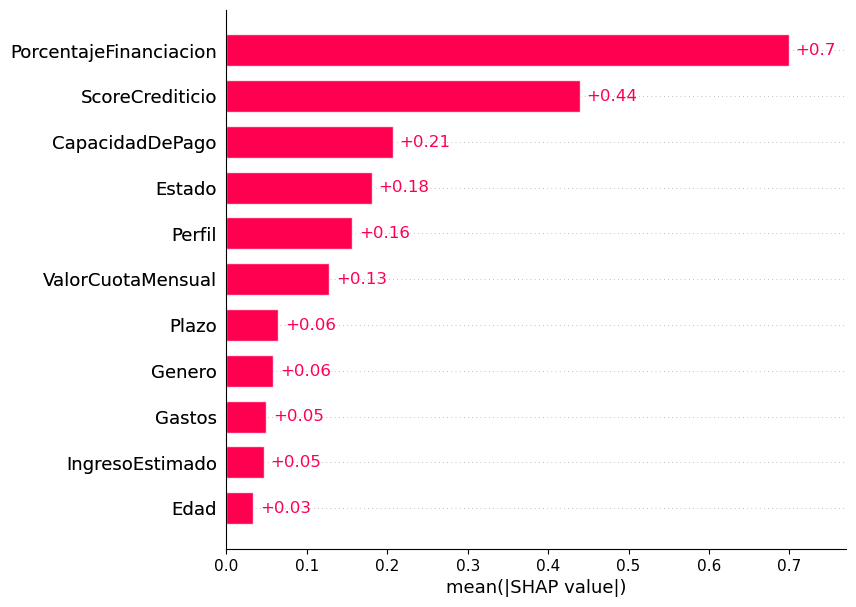

In [15]:
shap.plots.bar(shap_values, max_display=X_test.shape[1])